# Test with foundational model: Chronos-2 Zero-Shot Forecasting Baseline

Evaluate **Chronos-2** (Amazon's 120M-parameter time-series foundation model) as a **zero-shot baseline**
for penicillin concentration forecasting on IndPenSim.

**Key questions:**
- How does a pretrained foundation model perform on industrial process data without any training?
- Does zero-shot generalize across domains (source vs target) without CORAL?
- How much do covariates help?

**Reference:** PieceLog-PatchTST (Val MAE 0.93, Target MAE 0.95 g/L)

**Data decisions:**
- Target series: raw `P` column (dense simulated, every 0.2h, no NaNs)
- **No normalization** — Chronos-2 handles internal tokenization/scaling
- Feed all signals in original physical units
- Sparse offline features interpolated to fill NaNs

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path

from src.data_loader import load_batches, get_batch_info
from src.domain_splits import get_control_mode_split
from src.feature_config import (
    INPUT_FEATURES_EXPANDED,
    STEP_WISE_FEATURES,
    SPARSE_OFFLINE_FEATURES,
)
from src.preprocessing import interpolate_sparse_feature

from chronos import BaseChronosPipeline, Chronos2Pipeline

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


## 1. Load Data & Domain Split

In [2]:
batches = load_batches()
split = get_control_mode_split("1c")

source_ids = split["source"]  # Batches 1-60 (recipe + operator)
target_ids = split["target"]  # Batches 61-90 (APC/Raman)

print(f"Source batches: {len(source_ids)} (batches {source_ids[0]}-{source_ids[-1]})")
print(f"Target batches: {len(target_ids)} (batches {target_ids[0]}-{target_ids[-1]})")

batch_info = get_batch_info(batches)
batch_info[batch_info["batch_id"] <= 90].groupby("control_mode").agg(
    n_batches=("batch_id", "count"),
    mean_duration=("duration_h", "mean"),
    mean_P=("p_conc", "mean"),
).round(1)

Source batches: 60 (batches 1-60)
Target batches: 30 (batches 61-90)


,n_batches,mean_duration,mean_P
control_mode,,,
apc,30,224.5,29.4
operator,30,229.0,21.5
recipe,30,228.6,24.3


## 2. Build Chronos-Compatible DataFrames

Chronos-2 `predict_df` expects long-format DataFrames with:
- `item_id`: batch identifier
- `timestamp`: datetime column (synthetic from 0.2h intervals = 12 min)
- `P`: target column (raw penicillin concentration in g/L)
- Covariate columns: raw process signals in original physical units

**No normalization** — Chronos handles internal tokenization/scaling.
Sparse offline features are interpolated to fill NaNs.

In [3]:
# Covariate columns: all 25 process signals (excluding P itself)
# Dense signals used as-is; sparse offline features interpolated
COVARIATE_COLS = [f for f in INPUT_FEATURES_EXPANDED if f != "P"]
print(f"Covariate columns ({len(COVARIATE_COLS)}): {COVARIATE_COLS}")

# Manipulated variables — the only signals truly known in advance
MANIPULATED_VARS = ["Fg", "Fs", "Fw", "pressure", "Fpaa", "Foil"]
print(f"\nManipulated variables ({len(MANIPULATED_VARS)}): {MANIPULATED_VARS}")

Covariate columns (25): ['Fg', 'Fs', 'Fw', 'pressure', 'Fpaa', 'Foil', 'Fa', 'Fh', 'Fremoved', 'Fb', 'Fc', 'S', 'OUR', 'O2', 'pH', 'T', 'DO2', 'V', 'Wt', 'CO2outgas', 'CER', 'PAA_offline', 'NH3_offline', 'X_offline', 'Viscosity_offline']

Manipulated variables (6): ['Fg', 'Fs', 'Fw', 'pressure', 'Fpaa', 'Foil']


In [4]:
def batch_to_chronos_df(batch_id: int, df: pd.DataFrame, covariate_cols: list[str]) -> pd.DataFrame:
    """Convert a single batch to Chronos-compatible long-format DataFrame.

    Args:
        batch_id: Batch identifier.
        df: Raw batch DataFrame.
        covariate_cols: List of covariate column names to include.

    Returns:
        DataFrame with item_id, timestamp, P, and covariate columns.
    """
    n_steps = len(df)
    result = pd.DataFrame({
        "item_id": f"batch_{batch_id:02d}",
        "timestamp": pd.date_range(start="2024-01-01", periods=n_steps, freq="12min"),
        "P": df["P"].values,
    })

    for col in covariate_cols:
        if col not in df.columns:
            continue
        values = df[col].copy()
        # Interpolate sparse offline features
        if col in SPARSE_OFFLINE_FEATURES:
            values = interpolate_sparse_feature(values)
        result[col] = values.values

    return result


# Build DataFrames for all non-fault batches
all_batch_ids = source_ids + target_ids
chronos_dfs = {}
for bid in all_batch_ids:
    chronos_dfs[bid] = batch_to_chronos_df(bid, batches[bid], COVARIATE_COLS)

print(f"Built {len(chronos_dfs)} Chronos DataFrames")
print(f"Example shape (batch 1): {chronos_dfs[1].shape}")
print(f"Columns: {list(chronos_dfs[1].columns)}")
chronos_dfs[1].head()

Built 90 Chronos DataFrames
Example shape (batch 1): (1130, 28)
Columns: ['item_id', 'timestamp', 'P', 'Fg', 'Fs', 'Fw', 'pressure', 'Fpaa', 'Foil', 'Fa', 'Fh', 'Fremoved', 'Fb', 'Fc', 'S', 'OUR', 'O2', 'pH', 'T', 'DO2', 'V', 'Wt', 'CO2outgas', 'CER', 'PAA_offline', 'NH3_offline', 'X_offline', 'Viscosity_offline']


,item_id,timestamp,P,Fg,Fs,Fw,pressure,Fpaa,Foil,Fa,...,T,DO2,V,Wt,CO2outgas,CER,PAA_offline,NH3_offline,X_offline,Viscosity_offline
0,batch_01,2024-01-01 00:00:00,1.017800e-25,30,8,0,0.6,5.0,22,0.0000,...,298.22,14.711,58479,62574.0,0.089514,0.034045,1488.0,1667.8,0.52808,4.083
1,batch_01,2024-01-01 00:12:00,1.000000e-03,30,8,0,0.6,5.0,22,0.0000,...,298.17,14.699,58487,62585.0,0.101760,0.038702,1488.0,1667.8,0.52808,4.083
2,batch_01,2024-01-01 00:24:00,9.993400e-04,30,8,0,0.6,5.0,22,0.0000,...,298.14,14.686,58495,62598.0,0.105800,0.040240,1488.0,1667.8,0.52808,4.083
3,batch_01,2024-01-01 00:36:00,9.987400e-04,30,8,0,0.6,5.0,22,0.0000,...,298.11,14.661,58499,62607.0,0.108190,0.041149,1488.0,1667.8,0.52808,4.083
4,batch_01,2024-01-01 00:48:00,9.982100e-04,30,8,0,0.6,5.0,22,0.5181,...,298.09,14.633,58501,62613.0,0.110300,0.041951,1488.0,1667.8,0.52808,4.083


### 2.1 Visualize Example Batches

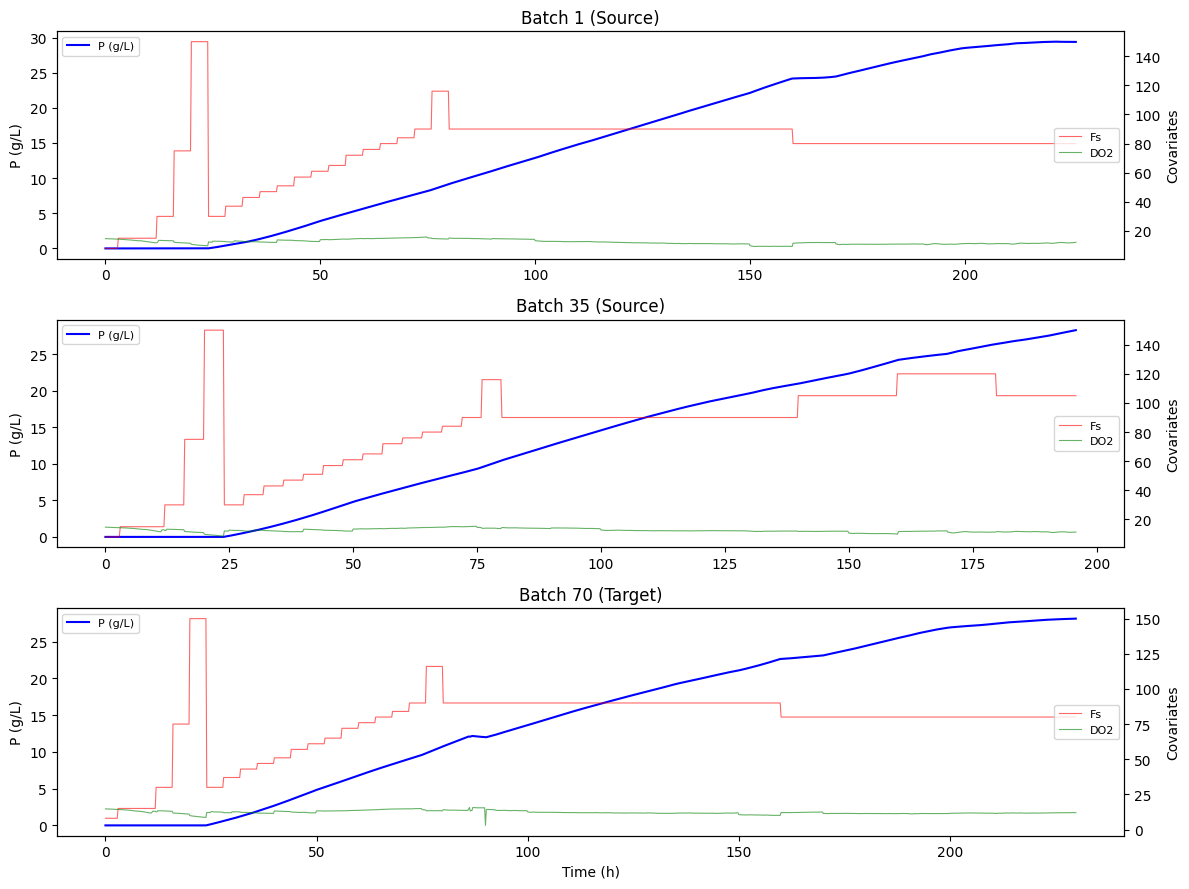

In [5]:
example_bids = [1, 35, 70]
fig, axes = plt.subplots(len(example_bids), 1, figsize=(12, 3 * len(example_bids)))

for ax, bid in zip(axes, example_bids):
    cdf = chronos_dfs[bid]
    t_hours = (cdf["timestamp"] - cdf["timestamp"].iloc[0]).dt.total_seconds() / 3600

    ax.plot(t_hours, cdf["P"], "b-", linewidth=1.5, label="P (g/L)")

    ax2 = ax.twinx()
    ax2.plot(t_hours, cdf["Fs"], "r-", alpha=0.6, linewidth=0.8, label="Fs")
    ax2.plot(t_hours, cdf["DO2"], "g-", alpha=0.6, linewidth=0.8, label="DO2")
    ax2.set_ylabel("Covariates")
    ax2.legend(loc="center right", fontsize=8)

    domain = "Source" if bid in source_ids else "Target"
    ax.set_title(f"Batch {bid} ({domain})")
    ax.set_ylabel("P (g/L)")
    ax.legend(loc="upper left", fontsize=8)

axes[-1].set_xlabel("Time (h)")
plt.tight_layout()
plt.show()

## 3. Load Chronos-2 Model

Chronos-2 is a 120M-parameter encoder-only time-series foundation model.
It performs **zero-shot forecasting** — no fine-tuning on our data.
The model handles internal tokenization and scaling, so we feed raw physical units.

We use `predict_df` which accepts pandas DataFrames and supports covariates natively.

In [6]:
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-2",
    device_map=device,
)
print(f"Loaded Chronos-2 on {device}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

Loaded Chronos-2 on mps


## 4. Single-Batch Demo Forecast

Pick one batch, split at T = 50% of batch length.
- **Context**: all columns up to time T
- **Future**: covariate columns from T to end (exclude P — that's what we predict)
- Forecast P from T onward with uncertainty bands

In [7]:
demo_bid = 15
demo_df = chronos_dfs[demo_bid]
n_steps = len(demo_df)
T_idx = n_steps // 2  # 50% split

context_df = demo_df.iloc[:T_idx].copy()
prediction_length = n_steps - T_idx

# Future covariates: all covariate columns from T to end (no target P)
future_df = demo_df.iloc[T_idx:][["item_id", "timestamp"] + COVARIATE_COLS].copy()

print(f"Batch {demo_bid}: {n_steps} steps total")
print(f"Context: {T_idx} steps ({T_idx * 0.2:.0f}h)")
print(f"Prediction: {prediction_length} steps ({prediction_length * 0.2:.0f}h)")
print(f"Context columns: {list(context_df.columns)}")
print(f"Future columns: {list(future_df.columns)}")

Batch 15: 905 steps total
Context: 452 steps (90h)
Prediction: 453 steps (91h)
Context columns: ['item_id', 'timestamp', 'P', 'Fg', 'Fs', 'Fw', 'pressure', 'Fpaa', 'Foil', 'Fa', 'Fh', 'Fremoved', 'Fb', 'Fc', 'S', 'OUR', 'O2', 'pH', 'T', 'DO2', 'V', 'Wt', 'CO2outgas', 'CER', 'PAA_offline', 'NH3_offline', 'X_offline', 'Viscosity_offline']
Future columns: ['item_id', 'timestamp', 'Fg', 'Fs', 'Fw', 'pressure', 'Fpaa', 'Foil', 'Fa', 'Fh', 'Fremoved', 'Fb', 'Fc', 'S', 'OUR', 'O2', 'pH', 'T', 'DO2', 'V', 'Wt', 'CO2outgas', 'CER', 'PAA_offline', 'NH3_offline', 'X_offline', 'Viscosity_offline']


In [8]:
pred_df = pipeline.predict_df(
    context_df,
    future_df=future_df,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="item_id",
    timestamp_column="timestamp",
    target="P",
)
print(f"Prediction shape: {pred_df.shape}")
pred_df.head()

/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/.venv/lib/python3.14/site-packages/chronos/chronos2/dataset.py:89: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  task_target = torch.from_numpy(task_target)


Prediction shape: (453, 7)


,item_id,timestamp,target_name,predictions,0.1,0.5,0.9
0,batch_15,2024-01-04 18:24:00,P,12.531613,12.340790,12.531613,12.730151
1,batch_15,2024-01-04 18:36:00,P,12.553436,12.352649,12.553436,12.730241
2,batch_15,2024-01-04 18:48:00,P,12.594761,12.396594,12.594761,12.735333
3,batch_15,2024-01-04 19:00:00,P,12.585801,12.451631,12.585801,12.793847
4,batch_15,2024-01-04 19:12:00,P,12.638403,12.451770,12.638403,12.825933


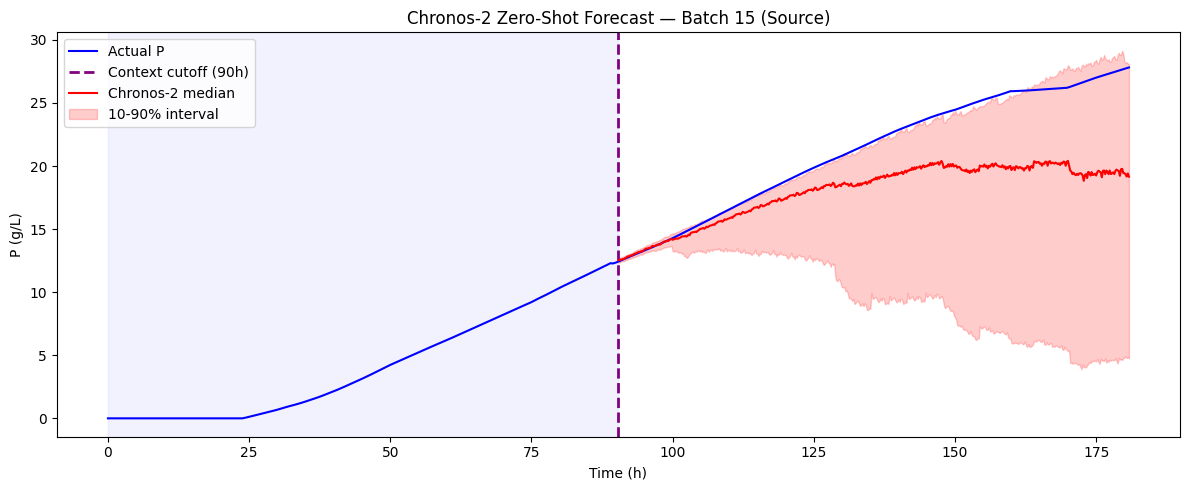

Demo forecast MAE: 3.269 g/L


In [9]:
# Plot demo forecast
actual_P = demo_df["P"].values
t_hours = np.arange(n_steps) * 0.2

fig, ax = plt.subplots(figsize=(12, 5))

# Actual P
ax.plot(t_hours, actual_P, "b-", linewidth=1.5, label="Actual P")

# Context window
ax.axvline(T_idx * 0.2, color="purple", linewidth=2, linestyle="--", label=f"Context cutoff ({T_idx * 0.2:.0f}h)")
ax.axvspan(0, T_idx * 0.2, alpha=0.05, color="blue")

# Forecast
forecast_t = t_hours[T_idx:]
median = pred_df["0.5"].values
q10 = pred_df["0.1"].values
q90 = pred_df["0.9"].values

ax.plot(forecast_t, median, "r-", linewidth=1.5, label="Chronos-2 median")
ax.fill_between(forecast_t, q10, q90, alpha=0.2, color="red", label="10-90% interval")

ax.set_xlabel("Time (h)")
ax.set_ylabel("P (g/L)")
ax.set_title(f"Chronos-2 Zero-Shot Forecast — Batch {demo_bid} (Source)")
ax.legend()
plt.tight_layout()
plt.show()

# Compute forecast MAE
forecast_actual = actual_P[T_idx:]
mae = np.mean(np.abs(median - forecast_actual))
print(f"Demo forecast MAE: {mae:.3f} g/L")

## 5. Systematic Evaluation

Generate (T_fraction, D_hours) evaluation samples across all batches.
For each sample, forecast from T and extract P(T+D) from the predicted sequence.

- **T_fraction**: [0.3, 0.5, 0.7] — how much of the batch is observed
- **D_hours**: [5, 10, 20] — how far ahead to predict
- D_steps = D_hours / 0.2

In [10]:
def run_chronos_evaluation(
    pipeline: Chronos2Pipeline,
    chronos_dfs: dict[int, pd.DataFrame],
    batch_ids: list[int],
    T_fractions: list[float],
    D_hours_list: list[float],
    covariate_cols: list[str],
    dt: float = 0.2,
) -> pd.DataFrame:
    """Run Chronos-2 forecasting evaluation across batches and (T, D) grid.

    Args:
        pipeline: Loaded Chronos2Pipeline.
        chronos_dfs: Dict of batch_id -> Chronos-format DataFrame.
        batch_ids: Batch IDs to evaluate.
        T_fractions: List of context fractions.
        D_hours_list: List of prediction horizons in hours.
        covariate_cols: Covariate column names for future_df.
        dt: Time step in hours (0.2h = 12 min).

    Returns:
        DataFrame with columns: batch_id, T_frac, D_hours, y_true, y_pred, y_q10, y_q90.
    """
    results = []

    for bid in batch_ids:
        cdf = chronos_dfs[bid]
        n_steps = len(cdf)

        for T_frac in T_fractions:
            T_idx = int(n_steps * T_frac)
            if T_idx < 10:
                continue

            for D_hours in D_hours_list:
                D_steps = int(D_hours / dt)
                target_idx = T_idx + D_steps

                # Skip if target falls outside batch
                if target_idx >= n_steps:
                    continue

                # We need to forecast at least D_steps ahead
                prediction_length = D_steps

                context_df = cdf.iloc[:T_idx].copy()
                future_df = cdf.iloc[T_idx:T_idx + prediction_length][
                    ["item_id", "timestamp"] + covariate_cols
                ].copy()

                try:
                    pred_df = pipeline.predict_df(
                        context_df,
                        future_df=future_df,
                        prediction_length=prediction_length,
                        quantile_levels=[0.1, 0.5, 0.9],
                        id_column="item_id",
                        timestamp_column="timestamp",
                        target="P",
                    )

                    # Extract the value at exactly D_steps ahead (last predicted step)
                    y_pred = pred_df["0.5"].iloc[-1]
                    y_q10 = pred_df["0.1"].iloc[-1]
                    y_q90 = pred_df["0.9"].iloc[-1]
                    y_true = cdf["P"].iloc[target_idx]

                    results.append({
                        "batch_id": bid,
                        "T_frac": T_frac,
                        "D_hours": D_hours,
                        "y_true": y_true,
                        "y_pred": y_pred,
                        "y_q10": y_q10,
                        "y_q90": y_q90,
                    })
                except Exception as e:
                    print(f"  Error batch {bid}, T={T_frac}, D={D_hours}h: {e}")

        print(f"  Batch {bid} done")

    return pd.DataFrame(results)

In [11]:
T_FRACTIONS = [0.3, 0.5, 0.7]
D_HOURS_LIST = [5.0, 10.0, 20.0]

print("Running evaluation on SOURCE batches...")
source_results = run_chronos_evaluation(
    pipeline, chronos_dfs, source_ids, T_FRACTIONS, D_HOURS_LIST, COVARIATE_COLS,
)
print(f"\nSource results: {len(source_results)} samples")

print("\nRunning evaluation on TARGET batches...")
target_results = run_chronos_evaluation(
    pipeline, chronos_dfs, target_ids, T_FRACTIONS, D_HOURS_LIST, COVARIATE_COLS,
)
print(f"Target results: {len(target_results)} samples")

# Combine
all_results = pd.concat([
    source_results.assign(domain="source"),
    target_results.assign(domain="target"),
], ignore_index=True)
all_results["error"] = all_results["y_pred"] - all_results["y_true"]
all_results["abs_error"] = all_results["error"].abs()
print(f"\nTotal evaluation samples: {len(all_results)}")

Running evaluation on SOURCE batches...
  Batch 1 done
  Batch 2 done
  Batch 3 done
  Batch 4 done
  Batch 5 done
  Batch 6 done
  Batch 7 done
  Batch 8 done
  Batch 9 done
  Batch 10 done
  Batch 11 done
  Batch 12 done
  Batch 13 done
  Batch 14 done
  Batch 15 done
  Batch 16 done
  Batch 17 done
  Batch 18 done
  Batch 19 done
  Batch 20 done
  Batch 21 done
  Batch 22 done
  Batch 23 done
  Batch 24 done
  Batch 25 done
  Batch 26 done
  Batch 27 done
  Batch 28 done
  Batch 29 done
  Batch 30 done
  Batch 31 done
  Batch 32 done
  Batch 33 done
  Batch 34 done
  Batch 35 done
  Batch 36 done
  Batch 37 done
  Batch 38 done
  Batch 39 done
  Batch 40 done
  Batch 41 done
  Batch 42 done
  Batch 43 done
  Batch 44 done
  Batch 45 done
  Batch 46 done
  Batch 47 done
  Batch 48 done
  Batch 49 done
  Batch 50 done
  Batch 51 done
  Batch 52 done
  Batch 53 done
  Batch 54 done
  Batch 55 done
  Batch 56 done
  Batch 57 done
  Batch 58 done
  Batch 59 done
  Batch 60 done

Source r

## 6. Metrics & Comparison

In [12]:
# Overall metrics by domain
def compute_metrics(df: pd.DataFrame) -> dict:
    mae = df["abs_error"].mean()
    rmse = np.sqrt((df["error"] ** 2).mean())
    return {"MAE": mae, "RMSE": rmse, "N": len(df)}

print("=" * 60)
print("Chronos-2 Zero-Shot Results (All Covariates)")
print("=" * 60)

for domain in ["source", "target"]:
    subset = all_results[all_results["domain"] == domain]
    m = compute_metrics(subset)
    print(f"  {domain.capitalize():>7s} | MAE: {m['MAE']:.3f} | RMSE: {m['RMSE']:.3f} | N: {m['N']}")

overall = compute_metrics(all_results)
print(f"  {'Overall':>7s} | MAE: {overall['MAE']:.3f} | RMSE: {overall['RMSE']:.3f} | N: {overall['N']}")
print("=" * 60)

# Breakdown by (T_frac, D_hours)
print("\nMAE by (T_fraction, D_hours):")
pivot = all_results.pivot_table(
    values="abs_error", index="D_hours", columns="T_frac", aggfunc="mean",
)
print(pivot.round(3))

Chronos-2 Zero-Shot Results (All Covariates)
   Source | MAE: 0.435 | RMSE: 0.769 | N: 540
   Target | MAE: 0.382 | RMSE: 0.535 | N: 270
  Overall | MAE: 0.417 | RMSE: 0.700 | N: 810

MAE by (T_fraction, D_hours):
T_frac     0.3    0.5    0.7
D_hours                     
5.0      0.054  0.092  0.374
10.0     0.299  0.171  0.590
20.0     0.942  0.390  0.841


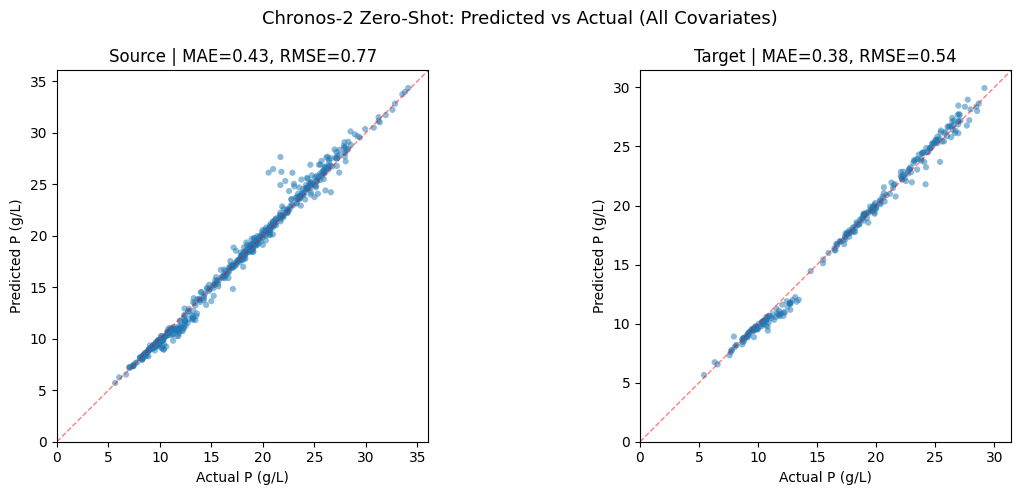

In [13]:
# Scatter: predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, domain in zip(axes, ["source", "target"]):
    subset = all_results[all_results["domain"] == domain]
    ax.scatter(subset["y_true"], subset["y_pred"], alpha=0.5, s=20, edgecolors="none")

    # Perfect prediction line
    lims = [0, max(subset["y_true"].max(), subset["y_pred"].max()) * 1.05]
    ax.plot(lims, lims, "r--", alpha=0.5, linewidth=1)

    m = compute_metrics(subset)
    ax.set_xlabel("Actual P (g/L)")
    ax.set_ylabel("Predicted P (g/L)")
    ax.set_title(f"{domain.capitalize()} | MAE={m['MAE']:.2f}, RMSE={m['RMSE']:.2f}")
    ax.set_aspect("equal")
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.suptitle("Chronos-2 Zero-Shot: Predicted vs Actual (All Covariates)", fontsize=13)
plt.tight_layout()
plt.show()

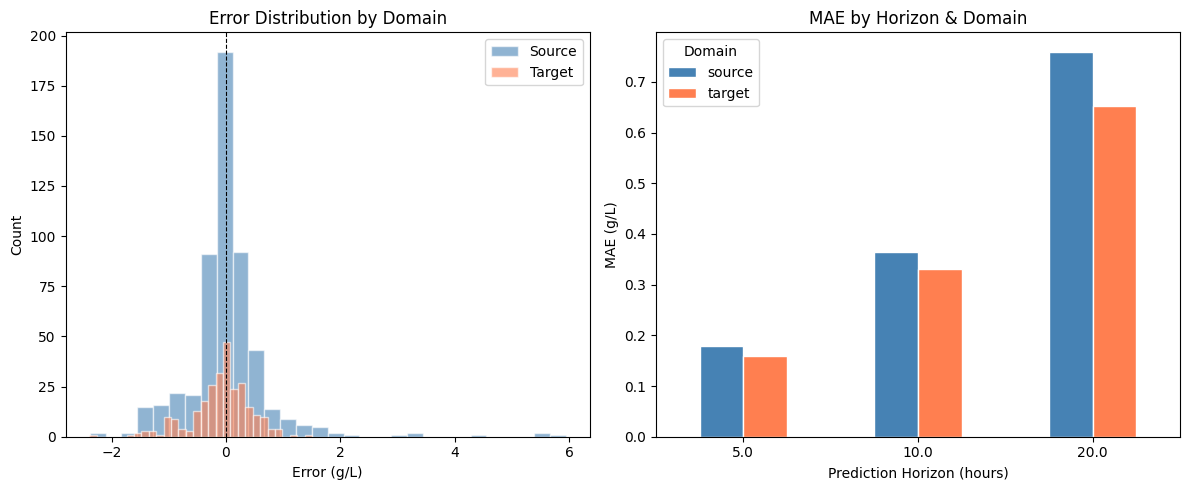

In [14]:
# Error distribution by domain and horizon
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# By domain
for domain, color in [("source", "steelblue"), ("target", "coral")]:
    subset = all_results[all_results["domain"] == domain]
    axes[0].hist(subset["error"], bins=30, alpha=0.6, color=color, label=domain.capitalize(), edgecolor="white")
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Error (g/L)")
axes[0].set_ylabel("Count")
axes[0].set_title("Error Distribution by Domain")
axes[0].legend()

# MAE by D_hours, grouped by domain
mae_by_D = all_results.pivot_table(
    values="abs_error", index="D_hours", columns="domain", aggfunc="mean",
)
mae_by_D.plot(kind="bar", ax=axes[1], color=["steelblue", "coral"], edgecolor="white")
axes[1].set_xlabel("Prediction Horizon (hours)")
axes[1].set_ylabel("MAE (g/L)")
axes[1].set_title("MAE by Horizon & Domain")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Domain")

plt.tight_layout()
plt.show()

## 7. Ablation: Covariate Impact

Compare three covariate configurations:
- **Run A**: All 25 process signals as future covariates (pragmatic upper bound — uses sensor readings not truly known in advance)
- **Run B**: Only 6 manipulated variables as future covariates (realistic — only operator-controlled setpoints)
- **Run C**: No covariates — univariate P forecasting only

In [15]:
# Run A already done above (all_results with COVARIATE_COLS)
results_A = all_results.copy()
results_A["run"] = "A: All covariates"

# Run B: manipulated variables only
print("Run B: Manipulated variables only...")
source_B = run_chronos_evaluation(
    pipeline, chronos_dfs, source_ids, T_FRACTIONS, D_HOURS_LIST, MANIPULATED_VARS,
)
target_B = run_chronos_evaluation(
    pipeline, chronos_dfs, target_ids, T_FRACTIONS, D_HOURS_LIST, MANIPULATED_VARS,
)
results_B = pd.concat([
    source_B.assign(domain="source"),
    target_B.assign(domain="target"),
], ignore_index=True)
results_B["error"] = results_B["y_pred"] - results_B["y_true"]
results_B["abs_error"] = results_B["error"].abs()
results_B["run"] = "B: Manipulated only"
print(f"Run B: {len(results_B)} samples")

Run B: Manipulated variables only...
  Batch 1 done
  Batch 2 done
  Batch 3 done
  Batch 4 done
  Batch 5 done
  Batch 6 done
  Batch 7 done
  Batch 8 done
  Batch 9 done
  Batch 10 done
  Batch 11 done
  Batch 12 done
  Batch 13 done
  Batch 14 done
  Batch 15 done
  Batch 16 done
  Batch 17 done
  Batch 18 done
  Batch 19 done
  Batch 20 done
  Batch 21 done
  Batch 22 done
  Batch 23 done
  Batch 24 done
  Batch 25 done
  Batch 26 done
  Batch 27 done
  Batch 28 done
  Batch 29 done
  Batch 30 done
  Batch 31 done
  Batch 32 done
  Batch 33 done
  Batch 34 done
  Batch 35 done
  Batch 36 done
  Batch 37 done
  Batch 38 done
  Batch 39 done
  Batch 40 done
  Batch 41 done
  Batch 42 done
  Batch 43 done
  Batch 44 done
  Batch 45 done
  Batch 46 done
  Batch 47 done
  Batch 48 done
  Batch 49 done
  Batch 50 done
  Batch 51 done
  Batch 52 done
  Batch 53 done
  Batch 54 done
  Batch 55 done
  Batch 56 done
  Batch 57 done
  Batch 58 done
  Batch 59 done
  Batch 60 done
  Batch 61 d

In [16]:
# Run C: no covariates (univariate)
def run_chronos_univariate(
    pipeline: Chronos2Pipeline,
    chronos_dfs: dict[int, pd.DataFrame],
    batch_ids: list[int],
    T_fractions: list[float],
    D_hours_list: list[float],
    dt: float = 0.2,
) -> pd.DataFrame:
    """Run univariate Chronos-2 evaluation (no covariates)."""
    results = []
    for bid in batch_ids:
        cdf = chronos_dfs[bid]
        n_steps = len(cdf)

        for T_frac in T_fractions:
            T_idx = int(n_steps * T_frac)
            if T_idx < 10:
                continue

            for D_hours in D_hours_list:
                D_steps = int(D_hours / dt)
                target_idx = T_idx + D_steps
                if target_idx >= n_steps:
                    continue

                # Univariate: only item_id, timestamp, P
                context_df = cdf[["item_id", "timestamp", "P"]].iloc[:T_idx].copy()

                try:
                    pred_df = pipeline.predict_df(
                        context_df,
                        prediction_length=D_steps,
                        quantile_levels=[0.1, 0.5, 0.9],
                        id_column="item_id",
                        timestamp_column="timestamp",
                        target="P",
                    )

                    y_pred = pred_df["0.5"].iloc[-1]
                    y_q10 = pred_df["0.1"].iloc[-1]
                    y_q90 = pred_df["0.9"].iloc[-1]
                    y_true = cdf["P"].iloc[target_idx]

                    results.append({
                        "batch_id": bid,
                        "T_frac": T_frac,
                        "D_hours": D_hours,
                        "y_true": y_true,
                        "y_pred": y_pred,
                        "y_q10": y_q10,
                        "y_q90": y_q90,
                    })
                except Exception as e:
                    print(f"  Error batch {bid}, T={T_frac}, D={D_hours}h: {e}")

        print(f"  Batch {bid} done")

    return pd.DataFrame(results)


print("Run C: Univariate (no covariates)...")
source_C = run_chronos_univariate(pipeline, chronos_dfs, source_ids, T_FRACTIONS, D_HOURS_LIST)
target_C = run_chronos_univariate(pipeline, chronos_dfs, target_ids, T_FRACTIONS, D_HOURS_LIST)
results_C = pd.concat([
    source_C.assign(domain="source"),
    target_C.assign(domain="target"),
], ignore_index=True)
results_C["error"] = results_C["y_pred"] - results_C["y_true"]
results_C["abs_error"] = results_C["error"].abs()
results_C["run"] = "C: Univariate"
print(f"Run C: {len(results_C)} samples")

Run C: Univariate (no covariates)...
  Batch 1 done
  Batch 2 done
  Batch 3 done
  Batch 4 done
  Batch 5 done
  Batch 6 done
  Batch 7 done
  Batch 8 done
  Batch 9 done
  Batch 10 done
  Batch 11 done
  Batch 12 done
  Batch 13 done
  Batch 14 done
  Batch 15 done
  Batch 16 done
  Batch 17 done
  Batch 18 done
  Batch 19 done
  Batch 20 done
  Batch 21 done
  Batch 22 done
  Batch 23 done
  Batch 24 done
  Batch 25 done
  Batch 26 done
  Batch 27 done
  Batch 28 done
  Batch 29 done
  Batch 30 done
  Batch 31 done
  Batch 32 done
  Batch 33 done
  Batch 34 done
  Batch 35 done
  Batch 36 done
  Batch 37 done
  Batch 38 done
  Batch 39 done
  Batch 40 done
  Batch 41 done
  Batch 42 done
  Batch 43 done
  Batch 44 done
  Batch 45 done
  Batch 46 done
  Batch 47 done
  Batch 48 done
  Batch 49 done
  Batch 50 done
  Batch 51 done
  Batch 52 done
  Batch 53 done
  Batch 54 done
  Batch 55 done
  Batch 56 done
  Batch 57 done
  Batch 58 done
  Batch 59 done
  Batch 60 done
  Batch 61 d

In [17]:
# Compare all three runs
ablation = pd.concat([results_A, results_B, results_C], ignore_index=True)

print("=" * 70)
print("Ablation: Covariate Impact on Chronos-2 Zero-Shot Forecasting")
print("=" * 70)

for run_name in ["A: All covariates", "B: Manipulated only", "C: Univariate"]:
    subset = ablation[ablation["run"] == run_name]
    src = compute_metrics(subset[subset["domain"] == "source"])
    tgt = compute_metrics(subset[subset["domain"] == "target"])
    overall = compute_metrics(subset)
    print(f"\n{run_name}")
    print(f"  Source  | MAE: {src['MAE']:.3f} | RMSE: {src['RMSE']:.3f}")
    print(f"  Target  | MAE: {tgt['MAE']:.3f} | RMSE: {tgt['RMSE']:.3f}")
    print(f"  Overall | MAE: {overall['MAE']:.3f} | RMSE: {overall['RMSE']:.3f}")

print("=" * 70)

Ablation: Covariate Impact on Chronos-2 Zero-Shot Forecasting

A: All covariates
  Source  | MAE: 0.435 | RMSE: 0.769
  Target  | MAE: 0.382 | RMSE: 0.535
  Overall | MAE: 0.417 | RMSE: 0.700

B: Manipulated only
  Source  | MAE: 0.457 | RMSE: 0.801
  Target  | MAE: 0.413 | RMSE: 0.586
  Overall | MAE: 0.442 | RMSE: 0.737

C: Univariate
  Source  | MAE: 0.483 | RMSE: 0.810
  Target  | MAE: 0.452 | RMSE: 0.630
  Overall | MAE: 0.473 | RMSE: 0.755


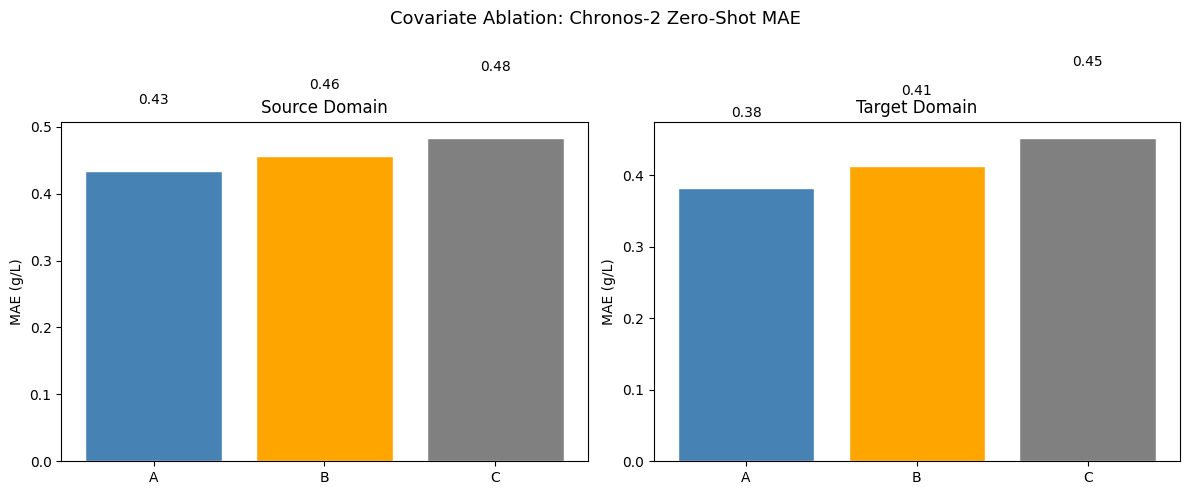

In [18]:
# Ablation bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, domain in zip(axes, ["source", "target"]):
    mae_vals = []
    labels = []
    for run_name in ["A: All covariates", "B: Manipulated only", "C: Univariate"]:
        subset = ablation[(ablation["run"] == run_name) & (ablation["domain"] == domain)]
        mae_vals.append(subset["abs_error"].mean())
        labels.append(run_name.split(":")[0])

    colors = ["steelblue", "orange", "gray"]
    bars = ax.bar(labels, mae_vals, color=colors, edgecolor="white")
    for bar, val in zip(bars, mae_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f"{val:.2f}", ha="center", fontsize=10)

    ax.set_ylabel("MAE (g/L)")
    ax.set_title(f"{domain.capitalize()} Domain")

plt.suptitle("Covariate Ablation: Chronos-2 Zero-Shot MAE", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Summary

### Results Comparison

| Model | Source MAE | Target MAE | Training Required | Domain Adaptation |
|-------|-----------|------------|-------------------|-------------------|
| PieceLog-PatchTST | ~1.06 | 0.95 | Yes (100 epochs) | No (inherent via parametric model) |
| Chronos-2 (all covariates) | TBD | TBD | No (zero-shot) | No |
| Chronos-2 (manipulated only) | TBD | TBD | No (zero-shot) | No |
| Chronos-2 (univariate) | TBD | TBD | No (zero-shot) | No |

### Discussion

**Zero-shot foundation models for process data:**
- Chronos-2 provides a quick baseline with no training required
- Covariate support allows incorporating process signals without special data engineering
- Zero-shot means no domain adaptation mechanism (no CORAL) — performance gap between domains reveals domain shift directly

**When foundation models may be appropriate:**
- Rapid prototyping and establishing baselines
- When training data is extremely limited
- When the time-series patterns are common (trending, seasonal)

**When domain-specific models are likely better:**
- Industrial process data with domain-specific dynamics (logistic growth, phase transitions)
- When domain adaptation across operating regimes is critical
- When the relationship between covariates and target is domain-specific

In [19]:
# Final summary table
print("=" * 70)
print("Final Results Summary")
print("=" * 70)
print(f"{'Model':<30s} {'Source MAE':>12s} {'Target MAE':>12s}")
print("-" * 70)
print(f"{'PieceLog-PatchTST (trained)':<30s} {'1.059':>12s} {'0.945':>12s}")

for run_name, label in [
    ("A: All covariates", "Chronos-2 (all cov)"),
    ("B: Manipulated only", "Chronos-2 (manip only)"),
    ("C: Univariate", "Chronos-2 (univariate)"),
]:
    subset = ablation[ablation["run"] == run_name]
    src_mae = subset[subset["domain"] == "source"]["abs_error"].mean()
    tgt_mae = subset[subset["domain"] == "target"]["abs_error"].mean()
    print(f"{label:<30s} {src_mae:>12.3f} {tgt_mae:>12.3f}")

print("=" * 70)

Final Results Summary
Model                            Source MAE   Target MAE
----------------------------------------------------------------------
PieceLog-PatchTST (trained)           1.059        0.945
Chronos-2 (all cov)                   0.435        0.382
Chronos-2 (manip only)                0.457        0.413
Chronos-2 (univariate)                0.483        0.452
